In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yaml, json, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.color": "#E5E5E5", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "font.family": "serif",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})

cfg    = yaml.safe_load(open("../config.yaml"))
TARGET = cfg["project"]["target_column"]

# Cargar dataset procesado
df = pd.read_parquet("../data/processed/train_features.parquet")
X  = df.drop(columns=[TARGET])
y  = df[TARGET]

print(f"✓ Dataset cargado: {X.shape[0]:,} filas × {X.shape[1]} features")
print(f"  Morosos: {y.sum():,} ({y.mean()*100:.1f}%)")

✓ Dataset cargado: 307,511 filas × 128 features
  Morosos: 24,825 (8.1%)


In [2]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=cfg["project"]["random_seed"],
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas")
print(f"Morosos en train antes de SMOTE: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")

smote = SMOTE(
    sampling_strategy=cfg["smote"]["sampling_strategy"],
    k_neighbors=cfg["smote"]["k_neighbors"],
    random_state=cfg["smote"]["random_state"]
)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)  # type: ignore

print(f"\n✓ Después de SMOTE:")
print(f"  Filas totales : {X_train_bal.shape[0]:,}")
print(f"  Morosos       : {y_train_bal.sum():,} ({y_train_bal.mean()*100:.1f}%)")

Train: 246,008 filas  |  Test: 61,503 filas
Morosos en train antes de SMOTE: 19,860 (8.1%)

✓ Después de SMOTE:
  Filas totales : 293,992
  Morosos       : 67,844 (23.1%)


In [3]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator

params = cfg["model"]["params"].copy()
params["random_state"] = cfg["project"]["random_seed"]

model = lgb.LGBMClassifier(**params)  # type: ignore

X_train_arr = np.array(X_train_bal)
y_train_arr = np.array(y_train_bal)

cv = StratifiedKFold(n_splits=cfg["model"]["cv_folds"], shuffle=True,
                     random_state=cfg["project"]["random_seed"])
cv_scores = cross_val_score(model, X_train_arr, y_train_arr,  # type: ignore
                            cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"Cross-validation ROC-AUC ({cfg['model']['cv_folds']} folds):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Media  : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}")

model.fit(X_train_arr, y_train_arr)
print(f"\n✓ Modelo entrenado")

Cross-validation ROC-AUC (5 folds):
  Fold 1: 0.9325
  Fold 2: 0.9283
  Fold 3: 0.9292
  Fold 4: 0.9306
  Fold 5: 0.9283

  Media  : 0.9298
  Std    : 0.0016

✓ Modelo entrenado


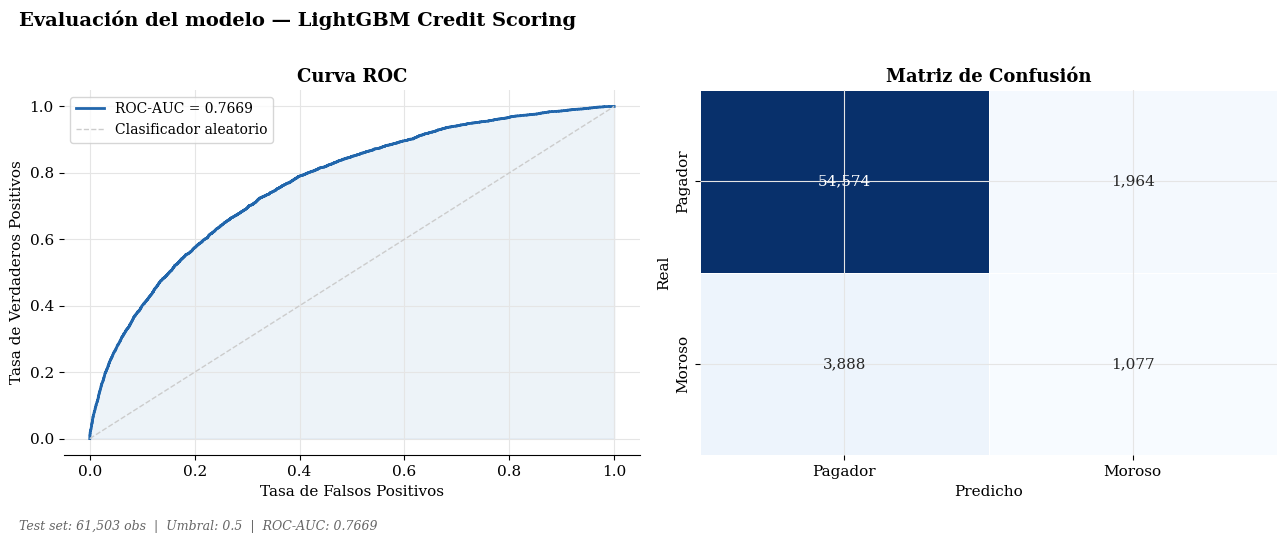


              precision    recall  f1-score   support

     Pagador       0.93      0.97      0.95     56538
      Moroso       0.35      0.22      0.27      4965

    accuracy                           0.90     61503
   macro avg       0.64      0.59      0.61     61503
weighted avg       0.89      0.90      0.89     61503



In [4]:
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)

X_test_arr  = np.array(X_test)
y_proba = np.array(model.predict_proba(X_test_arr))[:, 1]  # type: ignore
y_pred      = (y_proba >= cfg["model"]["decision_threshold"]).astype(int)
auc         = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Evaluación del modelo — LightGBM Credit Scoring",
             fontsize=14, fontweight="bold", x=0.02, ha="left", y=1.01)

ax = axes[0]
ax.plot(fpr, tpr, color="#2166AC", lw=2, label=f"ROC-AUC = {auc:.4f}")
ax.plot([0,1],[0,1], color="#CCCCCC", lw=1, linestyle="--", label="Clasificador aleatorio")
ax.fill_between(fpr, tpr, alpha=0.08, color="#2166AC")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curva ROC")
ax.legend(fontsize=10)

ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
            xticklabels=["Pagador","Moroso"],
            yticklabels=["Pagador","Moroso"],
            ax=ax2, cbar=False, linewidths=0.5)
ax2.set_title("Matriz de Confusión")
ax2.set_ylabel("Real")
ax2.set_xlabel("Predicho")

fig.text(0.02, -0.03,
    f"Test set: {len(y_test):,} obs  |  Umbral: {cfg['model']['decision_threshold']}  |  ROC-AUC: {auc:.4f}",
    fontsize=9, color="#666666", style="italic")

plt.tight_layout()
plt.savefig("../model/reports/03_roc_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n{classification_report(y_test, y_pred, target_names=['Pagador','Moroso'])}")

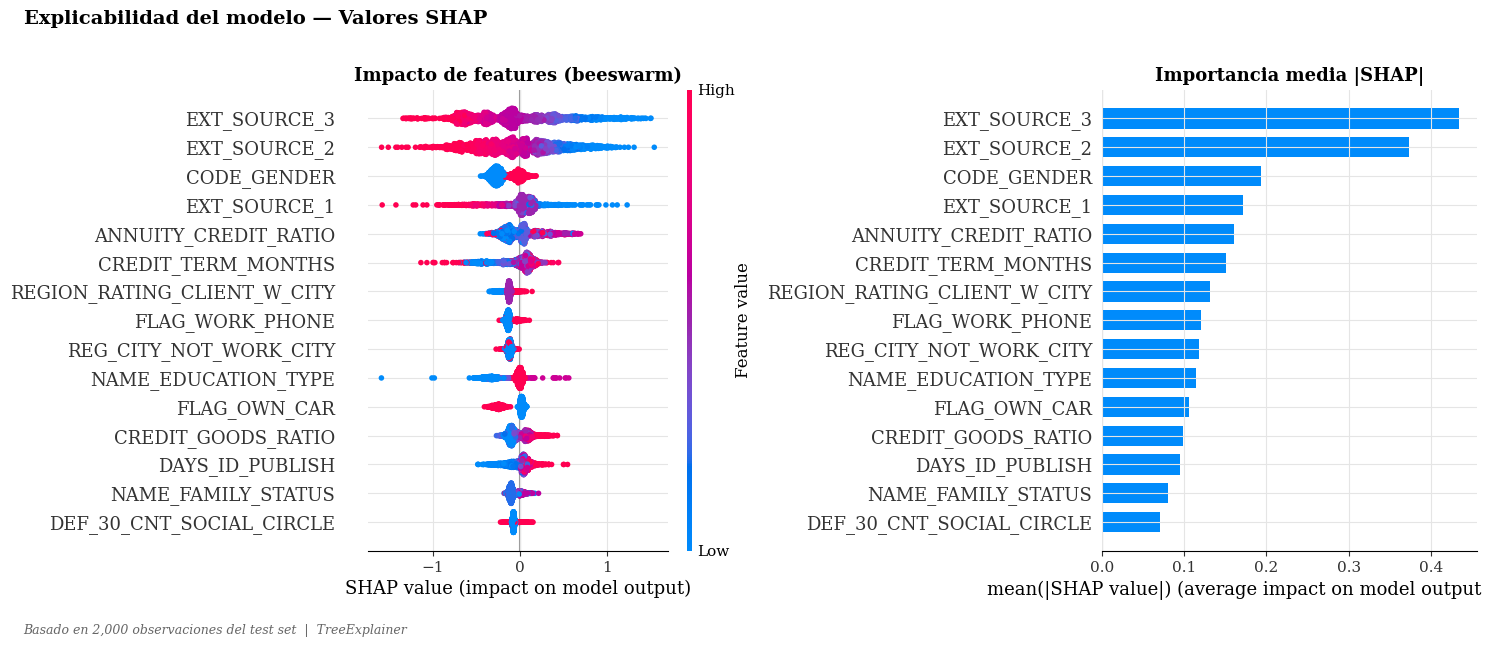

✓ Gráficas SHAP guardadas


In [5]:
import shap

# Calcular valores SHAP (muestra de 2000 para velocidad)
sample_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Si shap_values es lista (binario), tomar clase positiva
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Explicabilidad del modelo — Valores SHAP",
             fontsize=14, fontweight="bold", x=0.02, ha="left", y=1.01)

# ── Beeswarm (importancia + dirección) ───────────────────
plt.sca(axes[0])
shap.summary_plot(sv, X_sample, show=False, max_display=15,
                  color_bar=True, plot_size=None)
axes[0].set_title("Impacto de features (beeswarm)")

# ── Bar plot (importancia absoluta) ──────────────────────
plt.sca(axes[1])
shap.summary_plot(sv, X_sample, plot_type="bar", show=False,
                  max_display=15, plot_size=None)
axes[1].set_title("Importancia media |SHAP|")

fig.text(0.02, -0.03,
    f"Basado en {len(X_sample):,} observaciones del test set  |  TreeExplainer",
    fontsize=9, color="#666666", style="italic")

plt.tight_layout()
plt.savefig("../model/reports/04_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Gráficas SHAP guardadas")

In [6]:
import joblib

Path("../model/artifacts").mkdir(parents=True, exist_ok=True)

joblib.dump(model, "../model/artifacts/lgbm_model.joblib")

# Guardar métricas finales
metrics = {
    "roc_auc_test":      round(float(auc), 4),
    "roc_auc_cv_mean":   round(float(cv_scores.mean()), 4),
    "roc_auc_cv_std":    round(float(cv_scores.std()), 4),
    "n_train":           int(X_train_bal.shape[0]),
    "n_test":            int(X_test.shape[0]),
    "n_features":        int(X.shape[1]),
    "decision_threshold": cfg["model"]["decision_threshold"],
}
with open("../model/artifacts/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✓ lgbm_model.joblib   → model/artifacts/")
print("✓ metrics.json        → model/artifacts/")
print(f"\n  ROC-AUC final : {auc:.4f}")
print(f"  CV medio      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

✓ lgbm_model.joblib   → model/artifacts/
✓ metrics.json        → model/artifacts/

  ROC-AUC final : 0.7669
  CV medio      : 0.9298 ± 0.0016
